# AF4 – LMS Convergence Statistics

This notebook studies the convergence behavior of the LMS algorithm.

The notebook contains two parts:

1. **AR(1) process experiments**
   - reproduction of learning curves
   - transient weight response
   - random walk behavior
   - theory vs experiment

2. **Problem 17: AR(2) process**
   - calculation of noise variance
   - step-size justification
   - single realization analysis
   - ensemble-average learning curve
   - comparison with small step-size theory

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

## 1. AR(1) Process Setup

We first reproduce the LMS experiments for an AR(1) process:

\[
u(n) = -a\,u(n-1) + v(n)
\]

The LMS predictor uses one tap and estimates \( u(n) \) from \( u(n-1) \).
The optimal Wiener solution for this predictor is:

\[
w^\* = -a
\]

In [5]:
N_samples = 500
trials = 100
a = -0.99
sigma_u2 = 0.936
sigma_v2 = sigma_u2 * (1 - a**2)

print(f"sigma_u^2 = {sigma_u2:.4f}")
print(f"sigma_v^2 = {sigma_v2:.4f}")

def generate_ar1(N, a, sigma_v2, warmup=500):
    total = N + warmup
    u = np.zeros(total)
    v = np.random.randn(total) * np.sqrt(sigma_v2)

    for n in range(1, total):
        u[n] = -a * u[n-1] + v[n]

    return u[warmup:]

def lms_ar1(u, mu):
    N = len(u)
    w = np.zeros(N)
    e = np.zeros(N)

    e[0] = u[0]

    for n in range(1, N):
        u_hat = w[n-1] * u[n-1]
        e[n] = u[n] - u_hat
        w[n] = w[n-1] + mu * u[n-1] * e[n]

    return w, e

sigma_u^2 = 0.9360
sigma_v^2 = 0.0186


## 2. Figure 6.15 – Learning Curves

We compare the ensemble-average learning curves for different step sizes:

- \( \mu = 0.01 \)
- \( \mu = 0.05 \)
- \( \mu = 0.1 \)

For each value, the squared prediction error is averaged over multiple Monte Carlo runs.

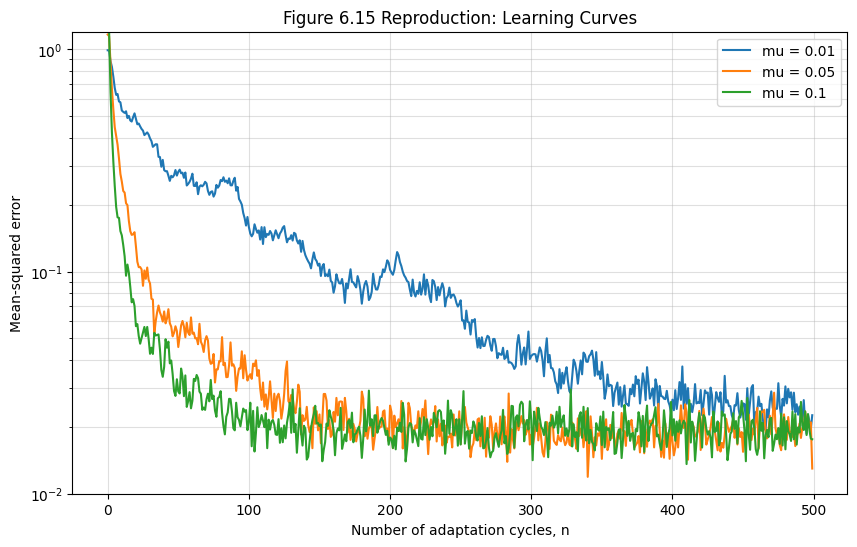

In [6]:
mu_values = [0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for mu in mu_values:
    mse_accum = np.zeros(N_samples)

    for _ in range(trials):
        u = generate_ar1(N_samples, a, sigma_v2)
        _, e = lms_ar1(u, mu)
        e[0] = u[0]
        mse_accum += e**2

    mse_avg = mse_accum / trials
    plt.plot(mse_avg, label=f"mu = {mu}")

plt.title("Figure 6.15 Reproduction: Learning Curves")
plt.xlabel("Number of adaptation cycles, n")
plt.ylabel("Mean-squared error")
plt.yscale("log")
plt.ylim(1e-2, 1.2)
plt.legend()
plt.grid(True, which="both", alpha=0.4)
plt.show()

### Observation

The learning curves show the standard LMS trade-off:

- smaller \( \mu \) gives slower convergence
- larger \( \mu \) gives faster convergence
- larger \( \mu \) also increases steady-state fluctuations

## 3. Figures 6.16 and 6.17 – Weight Behavior

Next, we study the weight trajectory for a very small step size.

- The full trajectory shows the transient convergence toward the Wiener solution.
- The zoomed version shows the random walk behavior around the optimum after convergence.

In [7]:
N_long = 25000
mu_small = 0.001

u_long = generate_ar1(N_long, a, sigma_v2)
w_long, e_long = lms_ar1(u_long, mu_small)

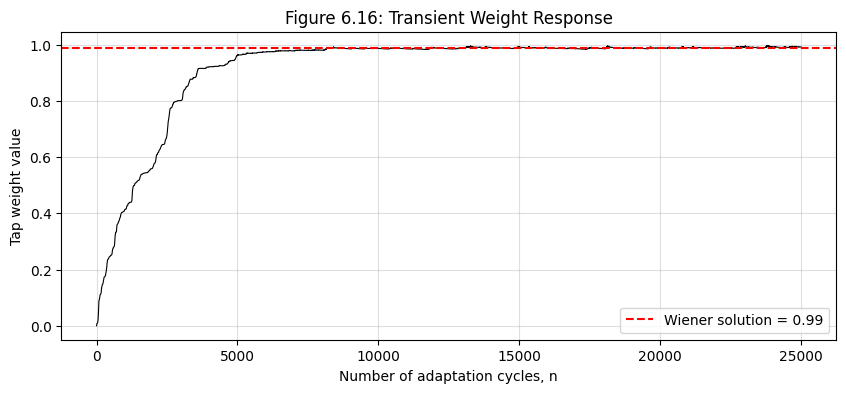

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(w_long, color="black", linewidth=0.8)
plt.axhline(-a, color="red", linestyle="--", label=f"Wiener solution = {-a:.2f}")
plt.title("Figure 6.16: Transient Weight Response")
plt.xlabel("Number of adaptation cycles, n")
plt.ylabel("Tap weight value")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

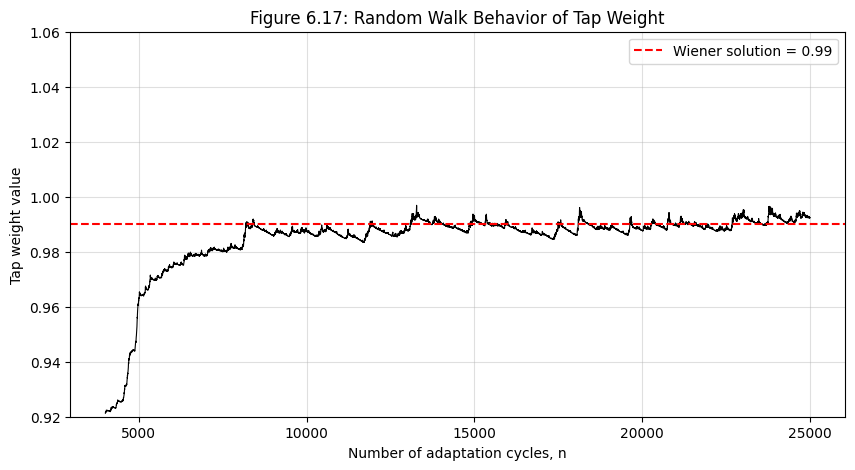

In [9]:
start_zoom = 4000

plt.figure(figsize=(10, 5))
plt.plot(np.arange(start_zoom, N_long), w_long[start_zoom:], color="black", linewidth=0.8)
plt.axhline(-a, color="red", linestyle="--", label=f"Wiener solution = {-a:.2f}")
plt.title("Figure 6.17: Random Walk Behavior of Tap Weight")
plt.xlabel("Number of adaptation cycles, n")
plt.ylabel("Tap weight value")
plt.ylim(0.92, 1.06)
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### Analysis

For \( \mu = 0.001 \), convergence is very slow but very stable.

This happens because:

- the LMS update is conservative
- the weight approaches the Wiener solution gradually
- after convergence, the weight does not become constant
- instead, it fluctuates around the optimum due to gradient noise

This fluctuation is the random walk behavior shown in Figure 6.17.

## 4. Figure 6.18 – Theory vs Experiment

We now compare the experimental learning curve with the theoretical small step-size prediction.

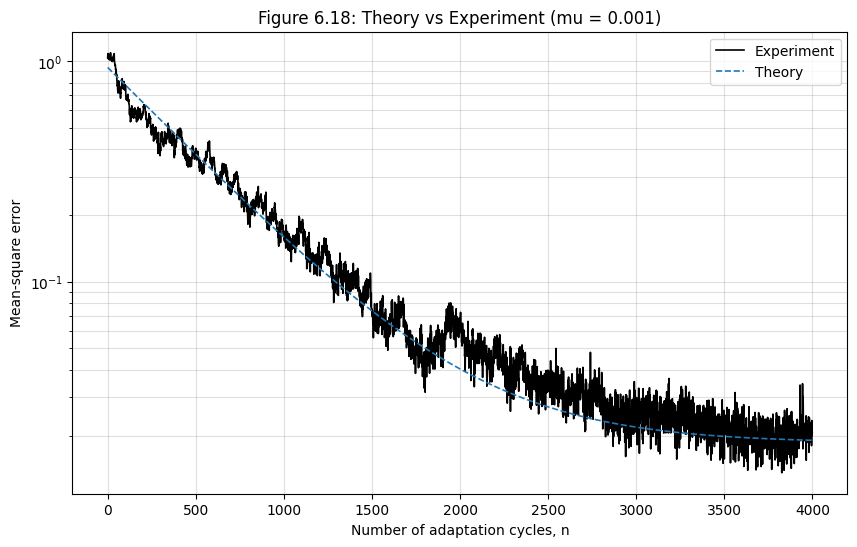

In [10]:
mu_theory = 0.001
N_theory = 4000
trials_theory = 100

mse_exp = np.zeros(N_theory)

for _ in range(trials_theory):
    u = generate_ar1(N_theory, a, sigma_v2)
    _, e = lms_ar1(u, mu_theory)
    e[0] = u[0]
    mse_exp += e**2

mse_exp /= trials_theory

n = np.arange(N_theory)
term1 = sigma_u2 * (1 - a**2) * (1 + 0.5 * mu_theory * sigma_u2)
term2 = sigma_u2 * (a**2 + 0.5 * mu_theory * a**2 * sigma_u2 - 0.5 * mu_theory * sigma_u2)
decay = (1 - mu_theory * sigma_u2) ** (2 * n)
J_theory = term1 + term2 * decay

plt.figure(figsize=(10, 6))
plt.semilogy(mse_exp, color="black", linewidth=1.2, label="Experiment")
plt.semilogy(J_theory, linestyle="--", linewidth=1.2, label="Theory")
plt.title(f"Figure 6.18: Theory vs Experiment (mu = {mu_theory})")
plt.xlabel("Number of adaptation cycles, n")
plt.ylabel("Mean-square error")
plt.legend()
plt.grid(True, which="both", alpha=0.4)
plt.show()

### Observation

The experimental and theoretical curves follow each other closely.

This confirms that for a sufficiently small step size, the LMS behavior is well described by small step-size theory.

# 5. Problem 17 – AR(2) Process

We now analyze the LMS predictor for the AR(2) process:

\[
u(n) = -a_1 u(n-1) - a_2 u(n-2) + v(n)
\]

with:

- \( a_1 = 0.1 \)
- \( a_2 = -0.8 \)
- target variance \( \sigma_u^2 = 1 \)
- step size \( \mu = 0.05 \)

## 5.1 Part (a) – Noise Variance Calculation

First, we calculate the required driving noise variance \( \sigma_v^2 \) that gives unit variance for the AR(2) process.

In [11]:
a1 = 0.1
a2 = -0.8
sigma_u2_target = 1.0
mu = 0.05

rho1 = -a1 / (1 + a2)
rho2 = -a1 * rho1 - a2
sigma_v2_ar2 = sigma_u2_target * (1 + a1 * rho1 + a2 * rho2)

print(f"rho1 = {rho1:.4f}")
print(f"rho2 = {rho2:.4f}")
print(f"sigma_v^2 = {sigma_v2_ar2:.4f}")

rho1 = -0.5000
rho2 = 0.8500
sigma_v^2 = 0.2700


### Result

Using the Yule-Walker relations, the required noise variance is:

\[
\sigma_v^2 = 0.27
\]

This value is used in all subsequent AR(2) simulations.

## 5.2 Part (b) – Step-Size Justification

We justify the choice \( \mu = 0.05 \) using the eigenvalues of the input correlation matrix.

In [12]:
R = np.array([[1, rho1],
              [rho1, 1]])

eigvals, eigvecs = np.linalg.eigh(R)
lambda_min = eigvals[0]
lambda_max = eigvals[1]

stability_limit = 2 / lambda_max
small_step_bound = 1 / (2 * lambda_max)

tau1 = -1 / (2 * np.log(1 - mu * eigvals[0]))
tau2 = -1 / (2 * np.log(1 - mu * eigvals[1]))

print("Eigenvalues:", eigvals)
print(f"lambda_max = {lambda_max:.4f}")
print(f"Stability condition: mu < {stability_limit:.4f}")
print(f"Small-step bound: mu << {small_step_bound:.4f}")
print(f"Chosen mu = {mu:.4f}")
print(f"tau1 = {tau1:.2f}")
print(f"tau2 = {tau2:.2f}")

Eigenvalues: [0.5 1.5]
lambda_max = 1.5000
Stability condition: mu < 1.3333
Small-step bound: mu << 0.3333
Chosen mu = 0.0500
tau1 = 19.75
tau2 = 6.41


### Interpretation

The chosen step size is safely below the stability limit and small enough for theoretical LMS approximations to remain valid.

This means the algorithm should:

- converge reliably
- remain stable
- allow comparison with theoretical predictions

## 5.3 AR(2) Signal Generation and LMS Predictor

In [13]:
def generate_ar2(N, a1, a2, sigma_v2, warmup=500):
    total = N + warmup
    u = np.zeros(total)
    v = np.random.randn(total) * np.sqrt(sigma_v2)

    for n in range(2, total):
        u[n] = -a1 * u[n-1] - a2 * u[n-2] + v[n]

    return u[warmup:]

def lms_ar2(u, mu):
    N = len(u)
    M = 2
    w = np.zeros((N, M))
    f = np.zeros(N)

    for n in range(M, N):
        x = np.array([u[n-1], u[n-2]])
        u_hat = np.dot(w[n-1], x)
        f[n] = u[n] - u_hat
        w[n] = w[n-1] + mu * f[n] * x

    return w, f

## 5.4 Part (c) – Single Realization

We now analyze one single realization of the AR(2) process.

We compare:

- prediction error \( f(n) \)
- tap-weight errors
- weight evolution
- power spectral densities

In [14]:
N_sim = 1000
np.random.seed(42)

u = generate_ar2(N_sim, a1, a2, sigma_v2_ar2)
w_hist, f_hist = lms_ar2(u, mu)

w1_opt = -a1
w2_opt = -a2

epsilon1 = w1_opt - w_hist[:, 0]
epsilon2 = w2_opt - w_hist[:, 1]

print(f"w1* = {w1_opt:.4f}")
print(f"w2* = {w2_opt:.4f}")
print(f"final w1 = {w_hist[-1,0]:.4f}")
print(f"final w2 = {w_hist[-1,1]:.4f}")
print(f"mean f = {np.mean(f_hist[100:]):.4f}")
print(f"var f = {np.var(f_hist[100:]):.4f}")

w1* = -0.1000
w2* = 0.8000
final w1 = 0.0795
final w2 = 0.8236
mean f = 0.0387
var f = 0.2828


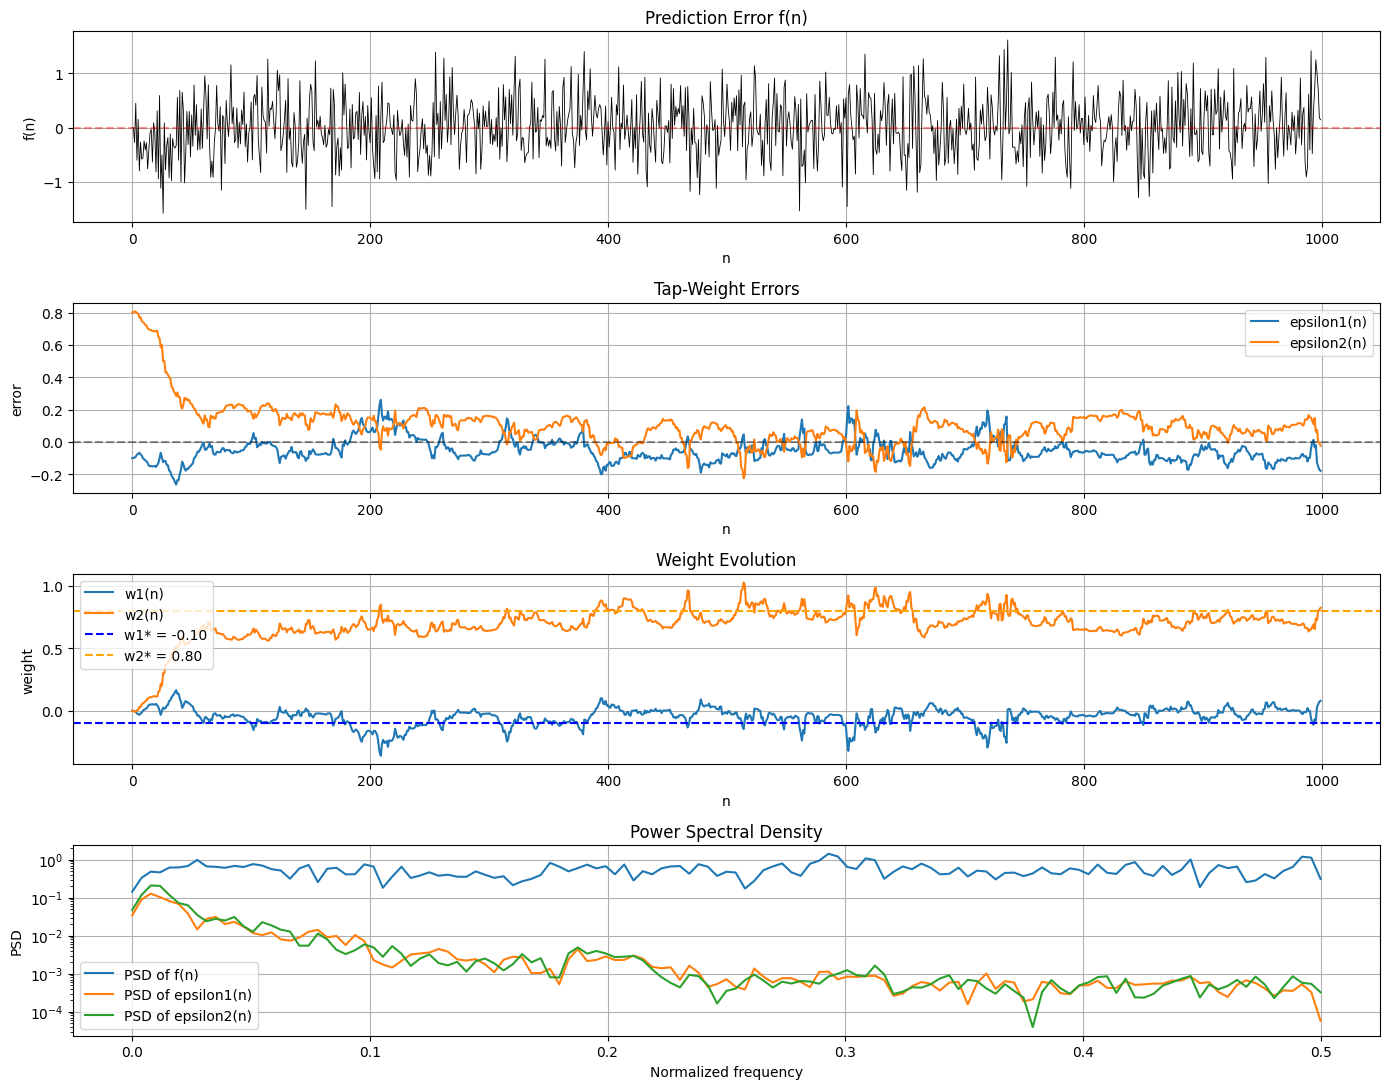

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11))

axes[0].plot(f_hist, color="black", lw=0.6)
axes[0].axhline(0, color="red", linestyle="--", alpha=0.4)
axes[0].set_title("Prediction Error f(n)")
axes[0].set_xlabel("n")
axes[0].set_ylabel("f(n)")

axes[1].plot(epsilon1, label="epsilon1(n)")
axes[1].plot(epsilon2, label="epsilon2(n)")
axes[1].axhline(0, color="black", linestyle="--", alpha=0.4)
axes[1].set_title("Tap-Weight Errors")
axes[1].set_xlabel("n")
axes[1].set_ylabel("error")
axes[1].legend()

axes[2].plot(w_hist[:, 0], label="w1(n)")
axes[2].plot(w_hist[:, 1], label="w2(n)")
axes[2].axhline(w1_opt, color="blue", linestyle="--", label=f"w1* = {w1_opt:.2f}")
axes[2].axhline(w2_opt, color="orange", linestyle="--", label=f"w2* = {w2_opt:.2f}")
axes[2].set_title("Weight Evolution")
axes[2].set_xlabel("n")
axes[2].set_ylabel("weight")
axes[2].legend()

freq_f, psd_f = welch(f_hist[200:], nperseg=256)
freq_e1, psd_e1 = welch(epsilon1[200:], nperseg=256)
freq_e2, psd_e2 = welch(epsilon2[200:], nperseg=256)

axes[3].semilogy(freq_f, psd_f, label="PSD of f(n)")
axes[3].semilogy(freq_e1, psd_e1, label="PSD of epsilon1(n)")
axes[3].semilogy(freq_e2, psd_e2, label="PSD of epsilon2(n)")
axes[3].set_title("Power Spectral Density")
axes[3].set_xlabel("Normalized frequency")
axes[3].set_ylabel("PSD")
axes[3].legend()

plt.tight_layout()
plt.show()

### Analysis

The prediction error behaves approximately as white noise:

- mean is close to zero
- variance is close to \( \sigma_v^2 \)

The tap-weight errors vary slowly, which is also visible in the PSD plots:
their energy is concentrated at low frequencies.

This agrees with LMS theory:
- the prediction error becomes white
- the weight errors are low-pass in nature

## 5.5 Parts (d) and (e) – Ensemble Learning Curve and Theory

Finally, we compare the ensemble-average learning curve with the small step-size theoretical prediction.

In [16]:
trials = 500
N_learn = 1000
mse_ensemble = np.zeros(N_learn)

for _ in range(trials):
    u = generate_ar2(N_learn, a1, a2, sigma_v2_ar2)
    _, f = lms_ar2(u, mu)
    mse_ensemble += f**2

mse_ensemble /= trials
steady_state_mse = np.mean(mse_ensemble[200:])

print(f"Experimental steady-state MSE = {steady_state_mse:.4f}")

Experimental steady-state MSE = 0.2866


In [17]:
w_opt = np.array([w1_opt, w2_opt])
v0 = w_opt - np.array([0.0, 0.0])
v0_eigen = eigvecs.T @ v0

J_min = sigma_v2_ar2
J_excess = mu * J_min * np.trace(R) / 2

n_vec = np.arange(N_learn)
J_theory = J_min * np.ones(N_learn)

for k in range(2):
    lambda_k = eigvals[k]
    vk0 = v0_eigen[k]
    J_theory += lambda_k * (vk0**2) * ((1 - mu * lambda_k) ** (2 * n_vec))

print(f"Theoretical steady-state MSE = {J_min + J_excess:.4f}")
print(f"Relative error = {100*np.abs(steady_state_mse - (J_min + J_excess)) / (J_min + J_excess):.2f}%")

Theoretical steady-state MSE = 0.2835
Relative error = 1.10%


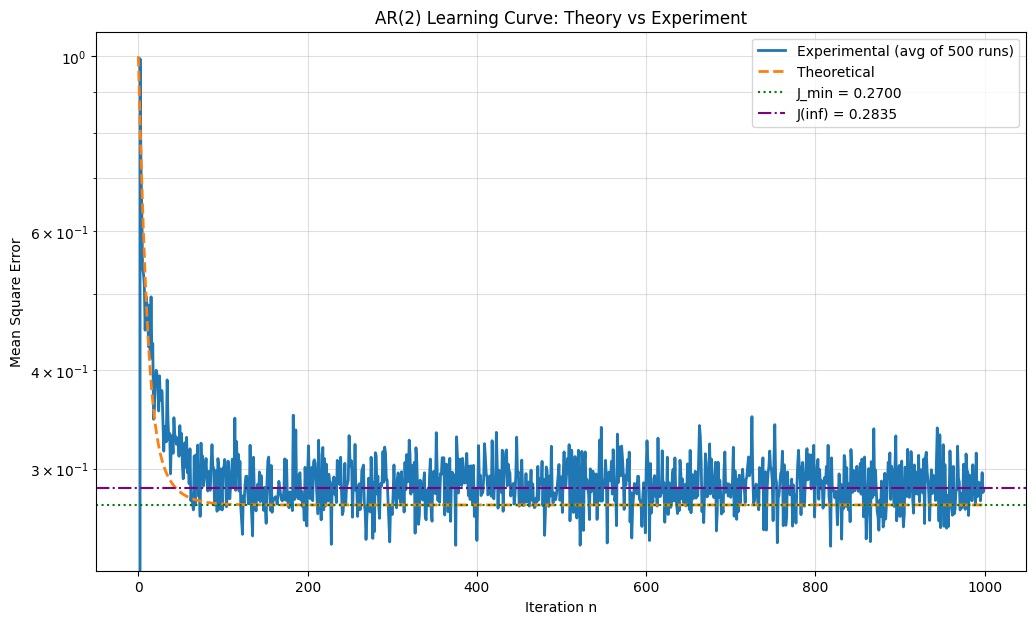

In [18]:
plt.figure(figsize=(12, 7))
plt.semilogy(mse_ensemble, label=f"Experimental (avg of {trials} runs)", linewidth=2)
plt.semilogy(J_theory, "--", label="Theoretical", linewidth=2)
plt.axhline(J_min, color="green", linestyle=":", label=f"J_min = {J_min:.4f}")
plt.axhline(J_min + J_excess, color="purple", linestyle="-.", label=f"J(inf) = {J_min + J_excess:.4f}")

plt.title("AR(2) Learning Curve: Theory vs Experiment")
plt.xlabel("Iteration n")
plt.ylabel("Mean Square Error")
plt.legend()
plt.grid(True, which="both", alpha=0.4)
plt.show()

### Final Comparison

The experimental ensemble-average learning curve matches the theoretical prediction very well.

This shows that:

- the LMS model is implemented correctly
- the chosen step size is appropriate
- the small step-size theory provides an accurate description of convergence behavior

# 6. Conclusion

This notebook analyzed LMS convergence for both AR(1) and AR(2) processes.

Main findings:

- larger step sizes converge faster but produce stronger fluctuations
- very small step sizes converge slowly but give smoother behavior
- the weight trajectory shows transient convergence followed by random walk behavior
- for the AR(2) process, the prediction error becomes approximately white
- the ensemble-average learning curve agrees closely with the theoretical LMS model

Overall, the experiments confirm the main convergence properties of the LMS algorithm.